# Multimodal Data Exploration

Our goal is to demonstrate how combining distinct data sources can reveal patterns. To do this, we will be looking at data from Michigan to see what we can discover.

We will be looking at two primary data sources: [**Public Elementary-Secondary Education Finance Data**](https://www2.census.gov/programs-surveys/school-finances/tables/2023/secondary-education-finance/elsec23.xlsx) and [**Michigan Cohort Graduation and Dropout Reports**](https://www.michigan.gov/cepi/-/media/Project/Websites/cepi/MISchoolData/2023-24/2024-Graduation-and-Dropout-Report-with-Subgroups.xlsx). To join these two data sources, we have to introduce a third data set from [**NCES CCD.**](https://nces.ed.gov/ccd/data/zip/ccd_lea_029_2223_w_1a_083023.zip)

## Loading Necessary Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [2]:
# Load in the graduation data and student info

grad = pd.read_excel(
    'data/michigan_school_info.xlsx',
    sheet_name='2024 4-Yr Grad Drop',
    skiprows=2
)

# Keep only district-level rows (no buildings, no statewide)
grad = grad[
    grad['BuildingCode'].isna() & 
    (grad['DistrictCode'] > 0)
].copy()

print(grad.shape)
grad.head()

(703, 18)


,District / Building Name (Code),Totals - \nFirst Time 9th Grade in Fall 2020,Totals - \n (+)Transfers In,Totals - \n (-)Transfers Out & Exempt,Totals - \nCohort Size,Cohort Status - \nNumber of On Time Graduates,Cohort Status - \nNumber of Dropouts,Cohort Status - \nNumber of Continuing in School,Cohort Status - \nNumber of Other Completers,Rates - \nGraduation Rate,Rates - \nDropout Rate,ISDCode,DistrictCode,BuildingCode,ISDName,DistrictName,BuildingName,Unnamed: 17
1,Adams Township School District (31020),49,7.0,4.0,52,46,< 10,< 10,< 10,0.8846,0.0192,31.0,31020.0,NaN,Copper Country ISD,Adams Township School District (31020),NaN,NaN
3,Addison Community Schools (46020),68,13.0,22.0,59,55,< 10,< 10,< 10,0.9322,0.0169,46.0,46020.0,NaN,Lenawee ISD,Addison Community Schools (46020),NaN,NaN
5,Adrian Public Schools (46010),221,41.0,44.0,218,178,28,12,< 10,0.8165,0.1284,46.0,46010.0,NaN,Lenawee ISD,Adrian Public Schools (46010),NaN,NaN
9,Airport Community Schools (58020),207,28.0,37.0,198,171,18,< 10,< 10,0.8636,0.0909,58.0,58020.0,NaN,Monroe ISD,Airport Community Schools (58020),NaN,NaN
14,Akron-Fairgrove Schools (79010),19,3.0,3.0,19,19,< 10,< 10,< 10,1.0000,0.0000,79.0,79010.0,NaN,Tuscola ISD,Akron-Fairgrove Schools (79010),NaN,NaN


In [3]:
# Load in the CCD data for the joins

ccd = pd.read_csv(
    'data/ccd_info.csv',
    encoding='latin1',
    low_memory=False
)

# Keep only Michigan and only the columns we need
ccd = ccd[ccd['FIPST'] == 26][['LEAID', 'ST_LEAID', 'LEA_NAME']].copy()

# Strip 'MI-' from ST_LEAID to get plain district code
ccd['dist_code'] = ccd['ST_LEAID'].str.replace('MI-', '', regex=False)

print(ccd.shape)
ccd.head()

(901, 4)


,LEAID,ST_LEAID,LEA_NAME,dist_code
7760,2600001,MI-84020,Michigan Department of Corrections,84020
7761,2600004,MI-84010,Michigan Department of Human Services,84010
7762,2600005,MI-13020,Battle Creek Public Schools,13020
7763,2600006,MI-27010,Bessemer Area School District,27010
7764,2600007,MI-32060,Harbor Beach Community Schools,32060


In [4]:
# Load in the district financial data

finance = pd.read_excel('data/census_financial.xlsx', sheet_name='elsec23')

# Keep only Michigan
finance = finance[finance['FIPST'] == 26].copy()

# Keep only the columns we need
finance = finance[[
    'NCESID', 'NAME', 'V33',       # ID and enrollment
    'TOTALREV', 'TFEDREV',          # total and federal revenue
    'TSTREV', 'TLOCREV',            # state and local revenue
    'TOTALEXP', 'TCURINST',         # total exp and instruction spending
    'TCURSSVC', 'TCAPOUT'           # support services and capital outlay
]].copy()

print(finance.shape)
finance.head()

(591, 11)


,NCESID,NAME,V33,TOTALREV,TFEDREV,TSTREV,TLOCREV,TOTALEXP,TCURINST,TCURSSVC,TCAPOUT
5274,2602160,ALCONA COMM SCHS,677,12739,1506,3237,7996,12406,6050,4613,1126
5275,2618570,HOPKINS PUBLIC SCHOOLS,1480,25220,1516,16673,7031,22700,12097,7720,1371
5276,2614230,FENNVILLE PUBLIC SCHOOLS,1247,23017,3185,12158,7674,22320,10920,7237,1525
5277,2635550,WAYLAND UNION SCHOOLS,2849,49763,3310,30354,16099,43035,23461,14105,657
5278,2680120,ALPENA-MONTMORENCY-ALCONA SCHOOL DIST,0,16997,2477,7762,6758,14689,1612,9585,290


A couple of things to note before we merge:

`grad` has 703 districts

`ccd` has 901 Michigan entries — more than `grad` because it includes all LEA types (intermediate districts, state agencies, etc.), not just regular districts

`finance` has 591 — fewer because not every Michigan district reports to the Census finance survey

In [5]:
# Prep the district code in grad to match ccd
grad['dist_code'] = grad['DistrictCode'].astype(int).astype(str).str.zfill(5)

# Merge grad with ccd to get the LEAID
grad_ccd = grad.merge(
    ccd[['LEAID', 'dist_code']],
    on='dist_code',
    how='inner'
)

print(grad_ccd.shape)
grad_ccd.head()

(703, 20)


,District / Building Name (Code),Totals - \nFirst Time 9th Grade in Fall 2020,Totals - \n (+)Transfers In,Totals - \n (-)Transfers Out & Exempt,Totals - \nCohort Size,Cohort Status - \nNumber of On Time Graduates,Cohort Status - \nNumber of Dropouts,Cohort Status - \nNumber of Continuing in School,Cohort Status - \nNumber of Other Completers,Rates - \nGraduation Rate,Rates - \nDropout Rate,ISDCode,DistrictCode,BuildingCode,ISDName,DistrictName,BuildingName,Unnamed: 17,dist_code,LEAID
0,Adams Township School District (31020),49,7.0,4.0,52,46,< 10,< 10,< 10,0.8846,0.0192,31.0,31020.0,NaN,Copper Country ISD,Adams Township School District (31020),NaN,NaN,31020,2601890
1,Addison Community Schools (46020),68,13.0,22.0,59,55,< 10,< 10,< 10,0.9322,0.0169,46.0,46020.0,NaN,Lenawee ISD,Addison Community Schools (46020),NaN,NaN,46020,2601920
2,Adrian Public Schools (46010),221,41.0,44.0,218,178,28,12,< 10,0.8165,0.1284,46.0,46010.0,NaN,Lenawee ISD,Adrian Public Schools (46010),NaN,NaN,46010,2601950
3,Airport Community Schools (58020),207,28.0,37.0,198,171,18,< 10,< 10,0.8636,0.0909,58.0,58020.0,NaN,Monroe ISD,Airport Community Schools (58020),NaN,NaN,58020,2601980
4,Akron-Fairgrove Schools (79010),19,3.0,3.0,19,19,< 10,< 10,< 10,1.0000,0.0000,79.0,79010.0,NaN,Tuscola ISD,Akron-Fairgrove Schools (79010),NaN,NaN,79010,2602010


In [6]:
# LEAID and NCESID are the same thing, just need matching types
grad_ccd['LEAID'] = grad_ccd['LEAID'].astype(str)
finance['NCESID'] = finance['NCESID'].astype(str)

# Final merge
michigan_merged = grad_ccd.merge(
    finance,
    left_on='LEAID',
    right_on='NCESID',
    how='inner'
)

# Drop rows where enrollment is 0 or missing
michigan_merged = michigan_merged[michigan_merged['V33'] > 0].copy()

print(f"Remaining districts: {len(michigan_merged)}")

Remaining districts: 509


The final result is 509 districts which is a solid dataset that we can work with. We can also clean up the column names to make them easier to work with.

In [7]:
print(michigan_merged.columns.tolist())

['District / Building Name (Code)', 'Totals - \nFirst Time 9th Grade in Fall 2020', 'Totals - \n (+)Transfers In', 'Totals - \n (-)Transfers Out & Exempt', 'Totals - \nCohort Size', 'Cohort Status - \nNumber of On Time Graduates', 'Cohort Status - \nNumber of Dropouts', 'Cohort Status - \nNumber of Continuing in School', 'Cohort Status - \nNumber of Other Completers', 'Rates - \nGraduation Rate', 'Rates - \nDropout Rate', 'ISDCode', 'DistrictCode', 'BuildingCode', 'ISDName', 'DistrictName', 'BuildingName', 'Unnamed: 17', 'dist_code', 'LEAID', 'NCESID', 'NAME', 'V33', 'TOTALREV', 'TFEDREV', 'TSTREV', 'TLOCREV', 'TOTALEXP', 'TCURINST', 'TCURSSVC', 'TCAPOUT']


In [8]:
# Rename graduation rate columns for clarity
michigan_merged = michigan_merged.rename(columns={
    'Rates - \nGraduation Rate': 'grad_rate',
    'Rates - \nDropout Rate': 'dropout_rate',
    'Cohort Status - \nNumber of On Time Graduates': 'num_graduates',
    'Cohort Status - \nNumber of Dropouts': 'num_dropouts',
    'Totals - \nCohort Size': 'cohort_size',
    'District / Building Name (Code)': 'district_building_name',
    'Totals - \nFirst Time 9th Grade in Fall 2020': 'first_time_9th_grade',
    'Totals - \n (+)Transfers In': 'transfers_in',
    'Totals - \n (-)Transfers Out & Exempt': 'transfers_out',
    'Cohort Status - \nNumber of Continuing in School': 'num_continuing',
    'Cohort Status - \nNumber of Other Completers': 'num_other_completers',
    'ISDCode': 'isd_code',
    'DistrictCode': 'district_code',
    'BuildingCode': 'building_code',
    'ISDName': 'isd_name',
    'DistrictName': 'district_name',
    'BuildingName': 'building_name',
    'Unnamed: 17': 'drop_col',
    'dist_code': 'mi_dist_code',
    'LEAID': 'leaid',
    'NCESID': 'ncesid',
    'NAME': 'census_name',
    'V33': 'enrollment',
    'TOTALREV': 'total_rev',
    'TFEDREV': 'federal_rev',
    'TSTREV': 'state_rev',
    'TLOCREV': 'local_rev',
    'TOTALEXP': 'total_exp',
    'TCURINST': 'instruction_exp',
    'TCURSSVC': 'support_services_exp',
    'TCAPOUT': 'capital_outlay'
})

michigan_merged.head()

,district_building_name,first_time_9th_grade,transfers_in,transfers_out,cohort_size,num_graduates,num_dropouts,num_continuing,num_other_completers,grad_rate,...,census_name,enrollment,total_rev,federal_rev,state_rev,local_rev,total_exp,instruction_exp,support_services_exp,capital_outlay
0,Adams Township School District (31020),49,7.0,4.0,52,46,< 10,< 10,< 10,0.8846,...,ADAMS TWP SCH DIST,466,7156,746,4940,1470,6852,4259,1743,175
1,Addison Community Schools (46020),68,13.0,22.0,59,55,< 10,< 10,< 10,0.9322,...,ADDISON COMM SCH DIST,717,12187,1511,4910,5766,11317,6502,3459,285
2,Adrian Public Schools (46010),221,41.0,44.0,218,178,28,12,< 10,0.8165,...,ADRIAN CITY SCH DIST,2771,53902,11407,30039,12456,52329,26215,15260,5710
3,Airport Community Schools (58020),207,28.0,37.0,198,171,18,< 10,< 10,0.8636,...,AIRPORT COMM SCH DIST,2809,46655,4981,30867,10807,43264,23392,11896,4638
4,Akron-Fairgrove Schools (79010),19,3.0,3.0,19,19,< 10,< 10,< 10,1.0000,...,AKRON-FAIRGROVE SCH DIST,340,7574,1840,3032,2702,7057,3242,2346,441


## Feature Engineering

Now that we have all of the data we need in one place, we can begin to do some feature engineering. 

The Census finance data stores all dollar figures in thousands of dollars — so a total_rev of 49,763 actually means $49,763,000. Dividing by enrollment gives you a per-student value, which is the only fair way to compare districts of wildly different sizes. A district with $50 million revenue and 2,000 students is very different from one with $50 million and 10,000 students.

In [9]:
# Finance figures are in thousands of dollars
# Multiply by 1000 then divide by enrollment to get per-student dollars

michigan_merged['ps_total_rev'] = (michigan_merged['total_rev'] * 1000) / michigan_merged['enrollment']
michigan_merged['ps_federal'] = (michigan_merged['federal_rev'] * 1000) / michigan_merged['enrollment']
michigan_merged['ps_state'] = (michigan_merged['state_rev'] * 1000) / michigan_merged['enrollment']
michigan_merged['ps_local'] = (michigan_merged['local_rev'] * 1000) / michigan_merged['enrollment']
michigan_merged['ps_instruction'] = (michigan_merged['instruction_exp'] * 1000) / michigan_merged['enrollment']
michigan_merged['ps_total_exp'] = (michigan_merged['total_exp'] * 1000) / michigan_merged['enrollment']

# Looking at districts and their enrollment + per-student funding
michigan_merged[['district_name', 'enrollment', 'ps_total_rev', 'ps_instruction']].head(10)

,district_name,enrollment,ps_total_rev,ps_instruction
0,Adams Township School District (31020),466,15356.223176,9139.484979
1,Addison Community Schools (46020),717,16997.210600,9068.340307
2,Adrian Public Schools (46010),2771,19452.183327,9460.483580
3,Airport Community Schools (58020),2809,16609.113564,8327.518690
4,Akron-Fairgrove Schools (79010),340,22276.470588,9535.294118
5,Alanson Public Schools (24030),229,20707.423581,9834.061135
6,Alba Public Schools (05010),96,19750.000000,8062.500000
7,Alcona Community Schools (01010),677,18816.838996,8936.484490
8,Algonac Community School District (74030),1364,18007.331378,7997.800587
9,Allegan Public Schools (03030),2198,18765.241128,8386.715196


The six new columns created:

- `ps_total_rev` — total revenue per student (all sources combined)

- `ps_federal` — federal funding per student

- `ps_state` — state funding per student 

- `ps_local` — local funding per student

- `ps_instruction` — spending per student on actual classroom instruction (teacher salaries, materials)

- `ps_total_exp` — total expenditure per student

## Analysis & Visualization

### Correlation Analysis

Now that we have our merged & cleaned dataset with per-student financial variables and graduation/dropout 
rates, we can begin to look into whether funding patterns are associated with student academic outcomes.

In [10]:
# Select the columns we want to correlate
corr_cols = [
    'grad_rate', 'dropout_rate',
    'ps_total_rev', 'ps_federal', 'ps_state', 'ps_local',
    'ps_instruction', 'ps_total_exp'
]

# Drop rows where grad_rate or dropout_rate is not numeric
# Just playing it safe since some districts have '< 10' value in columns related to dropouts
corr_df = michigan_merged[corr_cols].apply(pd.to_numeric, errors='coerce').dropna()

print(f"Districts used in correlation: {len(corr_df)}")

# Correlation matrix
corr_matrix = corr_df.corr()
corr_matrix

Districts used in correlation: 509


,grad_rate,dropout_rate,ps_total_rev,ps_federal,ps_state,ps_local,ps_instruction,ps_total_exp
grad_rate,1.000000,-0.823759,-0.146085,-0.361257,-0.145928,0.063317,0.026090,-0.060435
dropout_rate,-0.823759,1.000000,0.277260,0.405841,0.196598,0.060939,0.078749,0.162227
ps_total_rev,-0.146085,0.277260,1.000000,0.293991,0.674696,0.659088,0.632980,0.594273
ps_federal,-0.361257,0.405841,0.293991,1.000000,-0.005414,0.093736,0.152027,0.225961
ps_state,-0.145928,0.196598,0.674696,-0.005414,1.000000,-0.059272,0.069935,0.054177
ps_local,0.063317,0.060939,0.659088,0.093736,-0.059272,1.000000,0.805323,0.739497
ps_instruction,0.026090,0.078749,0.632980,0.152027,0.069935,0.805323,1.000000,0.786264
ps_total_exp,-0.060435,0.162227,0.594273,0.225961,0.054177,0.739497,0.786264,1.000000


### Correlation Matrix Heatmap

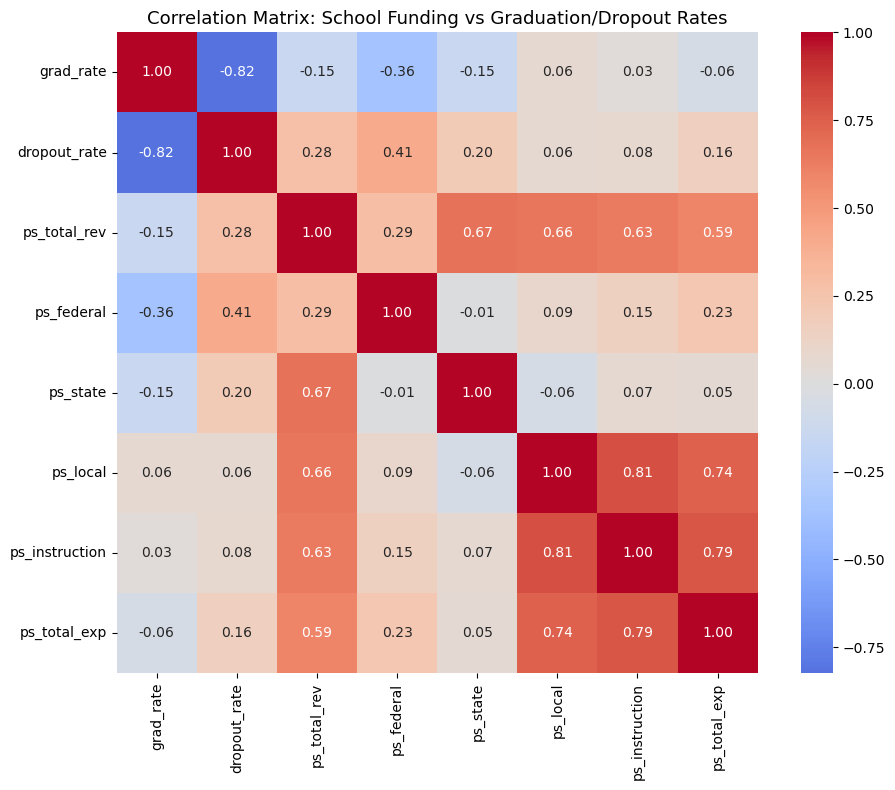

In [11]:
# Creating a correlation matrix to explore relationships between variables visually

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Matrix: School Funding vs Graduation/Dropout Rates', fontsize=13)
plt.tight_layout()
plt.show()

### Key Findings

`grad_rate` and `dropout_rate` = **-0.82**: This is a strong negative correlation, meaning they move in opposite directions as expected meaning our data looks to be working correctly. 

`ps_federal` and `dropout_rate` = **0.41**: Districts receiving more federal funding per student tend to have higher dropout rates. This sounds counterintuitive but makes sense. Federal [Title I funding](https://www.usnews.com/news/slideshows/which-schools-receive-the-most-title-i-funding) is mainly targeted at lower income districts, so higher federal money is actually a signal of poverty, not a cause of dropping out.

`ps_federal` and `grad_rate` = **-0.36**: Same story from the other direction

`ps_local`, `ps_instruction`, `ps_total_exp` all correlate strongly with each other (**0.74–0.81**) but show almost no relationship with grad or dropout rates (**near 0**). This means wealthier districts spend more overall but that spending alone doesn't predict graduation outcomes

`ps_state` shows almost no correlation with grad or dropout rates (**-0.15, 0.20**)

### Scatterplot

Graph showing per-student federal revenue vs dropout rate by district in Michigan

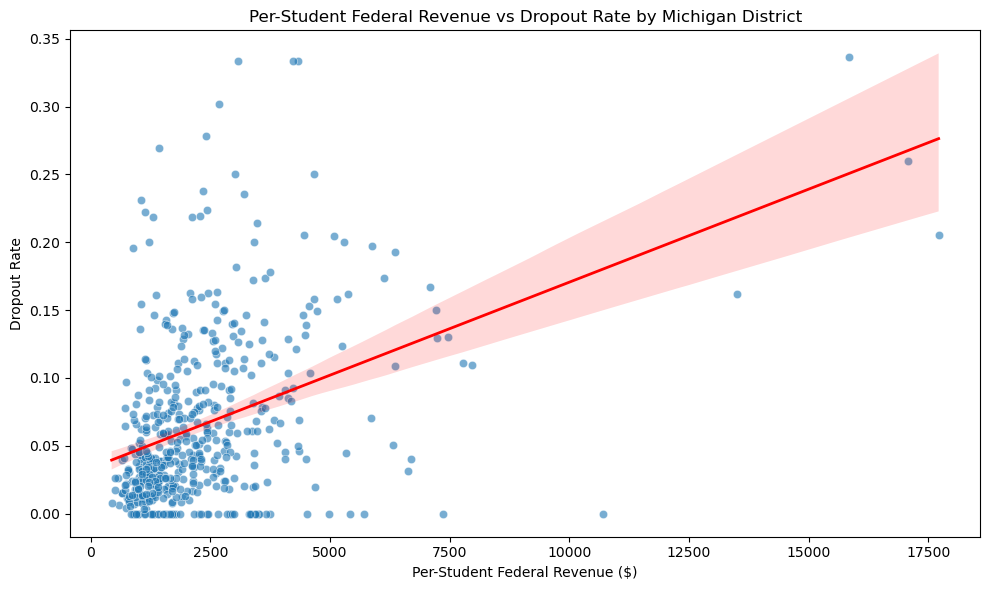

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=corr_df,
    x='ps_federal',
    y='dropout_rate',
    alpha=0.6
)

# Add regression line
sns.regplot(
    data=corr_df,
    x='ps_federal',
    y='dropout_rate',
    scatter=False,        # don't re-plot the dots, just the line
    color='red',
    line_kws={'linewidth': 2}
)

plt.title('Per-Student Federal Revenue vs Dropout Rate by Michigan District')
plt.xlabel('Per-Student Federal Revenue ($)')
plt.ylabel('Dropout Rate')
plt.tight_layout()
plt.show()

### Key Findings

**Regression line:** This line shows the overall trend which is as per-student federal revenue increases, dropout rate increases. The line starts around 0.04 dropout rate for districts with low federal funding and rises to around 0.25 for districts with the highest federal funding. This builds on the correlation value of 0.41 between the two variables.

**Confidence interval:** This shows the uncertainty around the trend line. The right side of the line begins to get much wider because there are very few districts on the high end of federal funding, so the model is less certain about the trend on that side. The narrow band on the left means we're more confident about the trend for typical districts.

**What this plot is telling you:** The relationship between these variables exist, but there's a lot of noise. The dots are spread widely above and below the line, which is why the correlation is only 0.41 and not stronger. As stated earlier, federal funding is a signal of need but it doesn't perfectly predict dropout rates on its own.

**One thing worth noting:** The wide confidence interval on the right and those extreme outlier dots above $10,000 per student are likely pulling the line upward more than they should. Those districts could be something atypical and worth looking into.

### Removing Heavily Federally Funded Districts 

Districts removed: 5
Remaining districts: 504


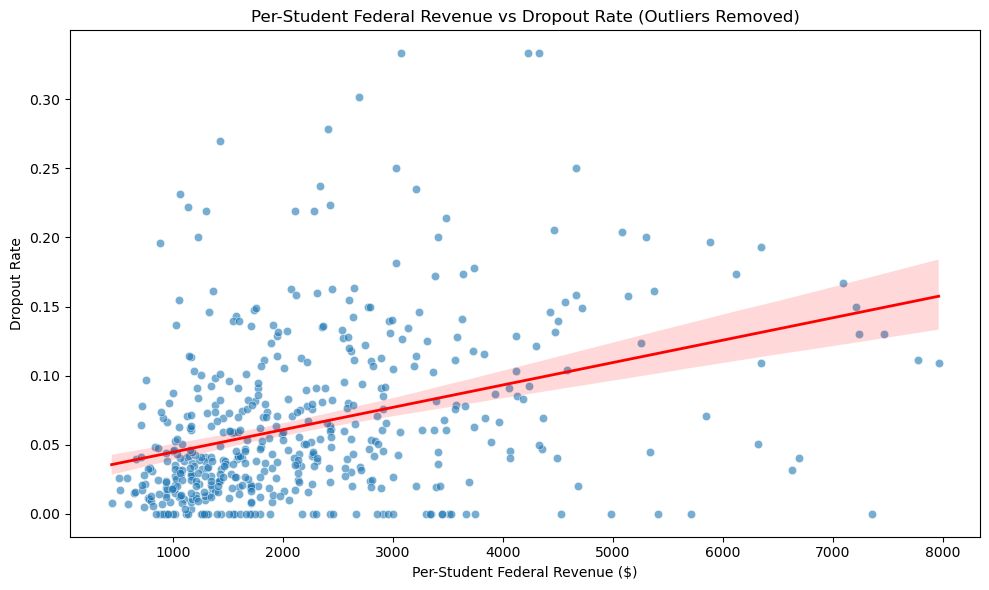

In [13]:
# Filter out extreme outliers in federal funding
corr_df_filtered = corr_df[corr_df['ps_federal'] < 10000].copy()

print(f"Districts removed: {len(corr_df) - len(corr_df_filtered)}")
print(f"Remaining districts: {len(corr_df_filtered)}")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=corr_df_filtered,
    x='ps_federal',
    y='dropout_rate',
    alpha=0.6
)

sns.regplot(
    data=corr_df_filtered,
    x='ps_federal',
    y='dropout_rate',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2}
)

plt.title('Per-Student Federal Revenue vs Dropout Rate (Outliers Removed)')
plt.xlabel('Per-Student Federal Revenue ($)')
plt.ylabel('Dropout Rate')
plt.tight_layout()
plt.show()

In [14]:
corr_filtered = corr_df_filtered[['ps_federal', 'dropout_rate']].corr()
print(corr_filtered)

              ps_federal  dropout_rate
ps_federal      1.000000      0.357553
dropout_rate    0.357553      1.000000


### What This Confirms

The relationship between federal funding and dropout rates is not only being driven by the extreme outliers we saw in the previous plot. Higher federal funding per student is associated with higher dropout rates. 

There are still some high dropout rate points (above 0.25) scattered across different funding levels that sit high above the trend line. Those are districts that have high dropout rates that can't be fully explained by their funding level alone which suggests other factors that are contributing to their numbers.

## Flagging

This section will go into defining at-risk districts based on the two variables we've been looking at (dropout rate & federal funding). At-risk districts are being defined as falling above the median dropout rate and median federal funding amount. 

This prioritizes districts where:
- The need is high 
- The outcomes are still poor despite resources being directed to the district

Naturally this method has some assumptions baked into it such as treating federal funding as a proxy for poverty, treating median as a reliable dividing line, and looking at things on a district level instead of specific schools. This approach is simple and interpretable and it's a good start before advancing to more complex solutions.

In [33]:
# Define at-risk thresholds
# High dropout = above the median dropout rate
# High federal funding = above the median federal per-student funding

dropout_threshold = corr_df_filtered['dropout_rate'].median()
federal_threshold = corr_df_filtered['ps_federal'].median()

print(f"Dropout rate threshold: {dropout_threshold:.3f}")
print(f"Federal funding threshold: {federal_threshold:.2f}")

# Flag districts that are above both thresholds
michigan_merged['at_risk'] = (
    (pd.to_numeric(michigan_merged['dropout_rate'], errors='coerce') > dropout_threshold) &
    (michigan_merged['ps_federal'] > federal_threshold)
)

print(f"\nTotal at-risk districts: {michigan_merged['at_risk'].sum()}")

Dropout rate threshold: 0.045
Federal funding threshold: 1825.29

Total at-risk districts: 171


In [34]:
at_risk_districts = michigan_merged[michigan_merged['at_risk'] == True][[
    'district_name', 'enrollment', 'grad_rate', 'dropout_rate',
    'ps_federal'
]].sort_values('dropout_rate', ascending=False)

at_risk_districts

,district_name,enrollment,grad_rate,dropout_rate,ps_federal
167,"Flint, School District of the City of (25010)",2840,0.4455,0.3366,15850.000000
6,Alba Public Schools (05010),96,0.3333,0.3333,3072.916667
25,Baldwin Community Schools (43040),442,0.5556,0.3333,4328.054299
73,Burt Township School District (02020),35,0.6667,0.3333,4228.571429
154,Engadine Consolidated Schools (49055),338,0.5238,0.3016,2686.390533
...,...,...,...,...,...
474,Wakefield-Marenisco School District (27070),252,0.9500,0.0500,4329.365079
504,"Wyandotte, School District of the City of (82170)",4318,0.8355,0.0484,2435.155164
111,Coleman Community Schools (56030),609,0.8372,0.0465,2781.609195
319,Mesick Consolidated Schools (83070),563,0.7674,0.0465,4357.015986


### Scatterplot

The visualization below shows where the median dropout rate and federal funding fall, risk status, and each districts location on the graph.

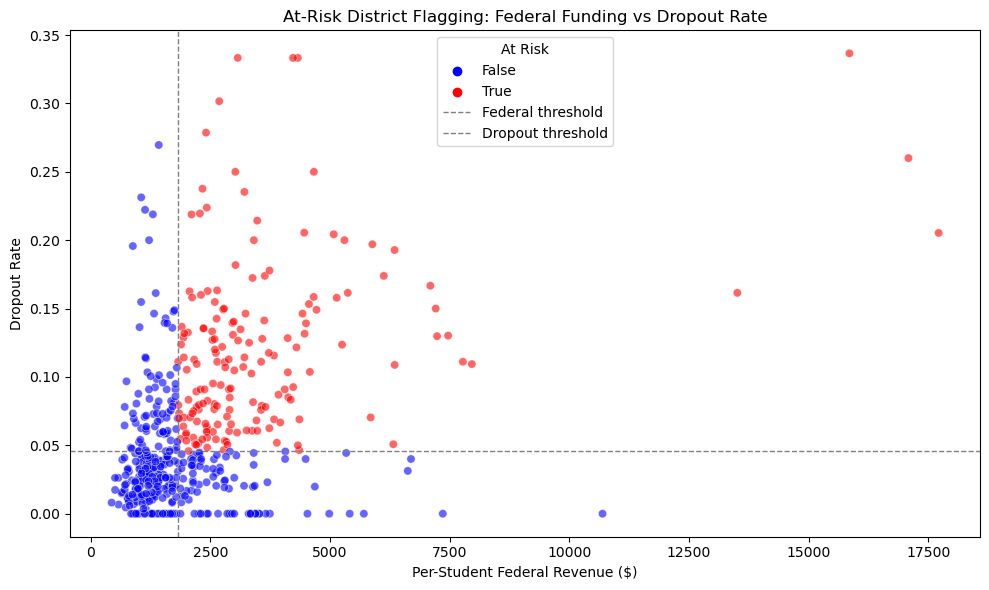

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=michigan_merged,
    x='ps_federal',
    y=pd.to_numeric(michigan_merged['dropout_rate'], errors='coerce'),
    hue='at_risk',
    palette={True: 'red', False: 'blue'},
    alpha=0.6
)

plt.axvline(x=federal_threshold, color='gray', linestyle='--', linewidth=1, label='Federal threshold')
plt.axhline(y=dropout_threshold, color='gray', linestyle='--', linewidth=1, label='Dropout threshold')

plt.title('At-Risk District Flagging: Federal Funding vs Dropout Rate')
plt.xlabel('Per-Student Federal Revenue ($)')
plt.ylabel('Dropout Rate')
plt.legend(title='At Risk')
plt.tight_layout()
plt.show()

### Key Findings

What the quadrants mean:

- **Upper right (flagged at-risk):** These are the districts with higher federal funding and dropout rates that are high need and still have students that are falling through with their education.

- **Upper left:** These districts have lower federal funding but high dropout rates. These districts should be flagged at-risk but are overlooked by the simplicity of the flagging process.

- **Lower right:** These districts have high federal funding and low dropout rates meaning something is working well. These are worth studying as a positive example to try and follow.

- **Lower left:** The majority of districts fall into this category of low dropout rates and low federal funding. These are typically the rural districts with lower poverty (lower federal funding is a key indicator).

## Reflection

### What We Did Manually

In this notebook we combined three different data sets
- Michigan graduation & dropout rates
- District-level school finance data
- Separate file to combine the other two datasets

Each dataset had different labels, units, etc. which made joining them require a fair amount of manual effort to understand the data. Obviously, by the time this data was collected, the students were either graduated or dropped out.

### Core Problem

Each educational dataset that's out there is formatted in dozens of different ways making it difficult to combine them into one unified dataset. Manually formatting this information can take significant time before the data is actually ready for analysis.

### How AI Can Change This

**Data Integration:** Rather than manually downloading files and joining them like we did, an AI system could continuously ingest data from different locations in real time. It could automatically map between different ID systems, handle missing values, etc. to maintain a clean record for each student, district, or school.

**Earlier Flagging:** Our system is looking at a yearly basis, but making a system that focuses on real-time data could help flag students or districts immediately, so they can get assistance before the end result (dropout/graduation).

**Improved At-Risk Flagging:** The current flagging method only looks at two binary thresholds. An AI system could use advanced machine learning models trained over years of historical data to produce a continuous risk score for each student using more variables. It could find which combination reliably predicts dropout rates to try to catch students earlier. 

### Limitations

In a perfect world this approach would work, but like a lot of other machine learning methods in the past, it raises ethical concerns. The book [Weapons of Math Destruction](https://en.wikipedia.org/wiki/Weapons_of_Math_Destruction) points out issues about bias, privacy, over-reliance, and interpretability that could arise from this approach. It's important to take these factors into account before implementing these methods.

### Conclusion

This analysis demonstrated how combining different datasets across different sources can reveal patterns such as the relationship between federal funding and dropout rates that neither dataset could show independently. It also revealed the limitations such as difficulty joining datasets, results too late to intervene, and missing true at-risk districts. AI systems to improve these limitations exist, but their implementation raises serious ethical and technical challenges that must be carefully considered.

